# PlantDoc Dataset Explorer
This notebook provides exploratory data analysis (EDA) for the PlantDoc dataset. It visualizes sample images, inspects the annotation format, and plots the distribution of classes.

In [ ]:
import os
import json
import random
import matplotlib.pyplot as plt
from PIL import Image, ImageDraw
from collections import Counter

# Define paths for the sourced PlantDoc dataset 
DATA_PATH = "data/raw/train"
ANNOTATION_PATH = os.path.join(DATA_PATH, "_annotations.coco.json")

if not os.path.exists(ANNOTATION_PATH):
    print(f" Could not find {ANNOTATION_PATH}")
    print("Please run `python data/download_data.py` to download the dataset before running this notebook.")
else:
    print(" Dataset found! Ready for EDA.")

✅ Dataset found! Ready for EDA.


In [2]:
if os.path.exists(ANNOTATION_PATH):
    with open(ANNOTATION_PATH) as f:
        coco_data = json.load(f)

    # Create category mapping
    categories = {cat['id']: cat['name'] for cat in coco_data['categories']}
    print(f"Total Images: {len(coco_data['images'])}")
    print(f"Total Annotations: {len(coco_data['annotations'])}")
    print(f"Number of Classes: {len(categories)}")

Total Images: 2344
Total Annotations: 8440
Number of Classes: 29


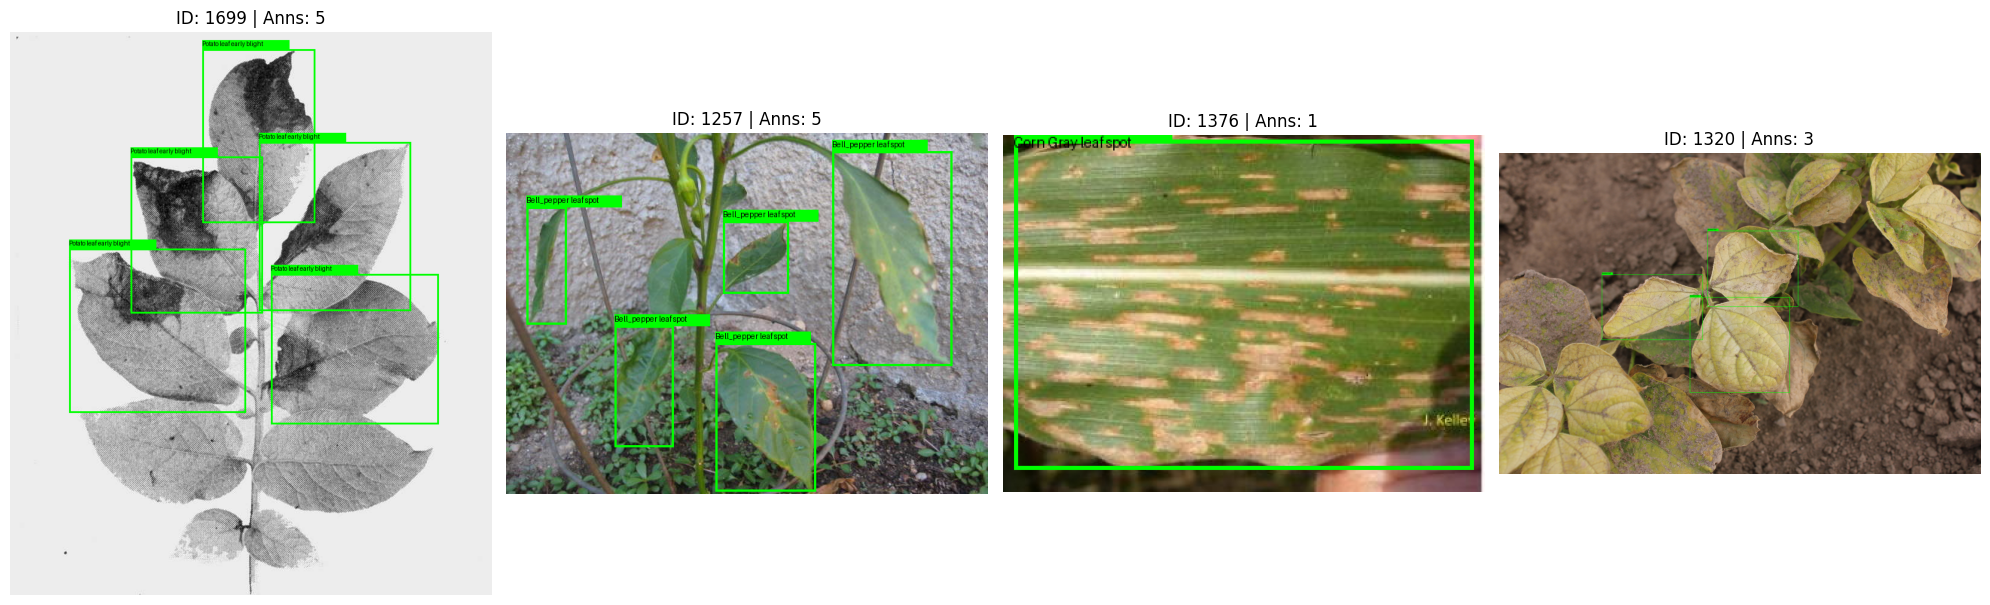

In [3]:
def plot_plant_samples(coco, img_dir, n=4):
    if not os.path.exists(img_dir): return
    sample_imgs = random.sample(coco['images'], min(n, len(coco['images'])))
    fig, axes = plt.subplots(1, n, figsize=(20, 6))
    if n == 1: axes = [axes]
    
    for i, img_info in enumerate(sample_imgs):
        img_path = os.path.join(img_dir, img_info['file_name'])
        if not os.path.exists(img_path):
            continue
        img = Image.open(img_path)
        draw = ImageDraw.Draw(img)
        
        # Get all disease annotations for this leaf
        anns = [a for a in coco['annotations'] if a['image_id'] == img_info['id']]
        
        for ann in anns:
            x, y, w, h = ann['bbox']
            label = categories.get(ann['category_id'], 'Unknown')
            draw.rectangle([x, y, x + w, y + h], outline="#00ff00", width=3)
            # draw simple text background
            draw.rectangle([x, max(0, y-15), x+len(label)*6, y], fill="#00ff00")
            draw.text((x, max(0, y-15)), label, fill="black")
            
        axes[i].imshow(img)
        axes[i].axis('off')
        axes[i].set_title(f"ID: {img_info['id']} | Anns: {len(anns)}")
        
    plt.tight_layout()
    plt.show()

if 'coco_data' in locals():
    plot_plant_samples(coco_data, DATA_PATH)

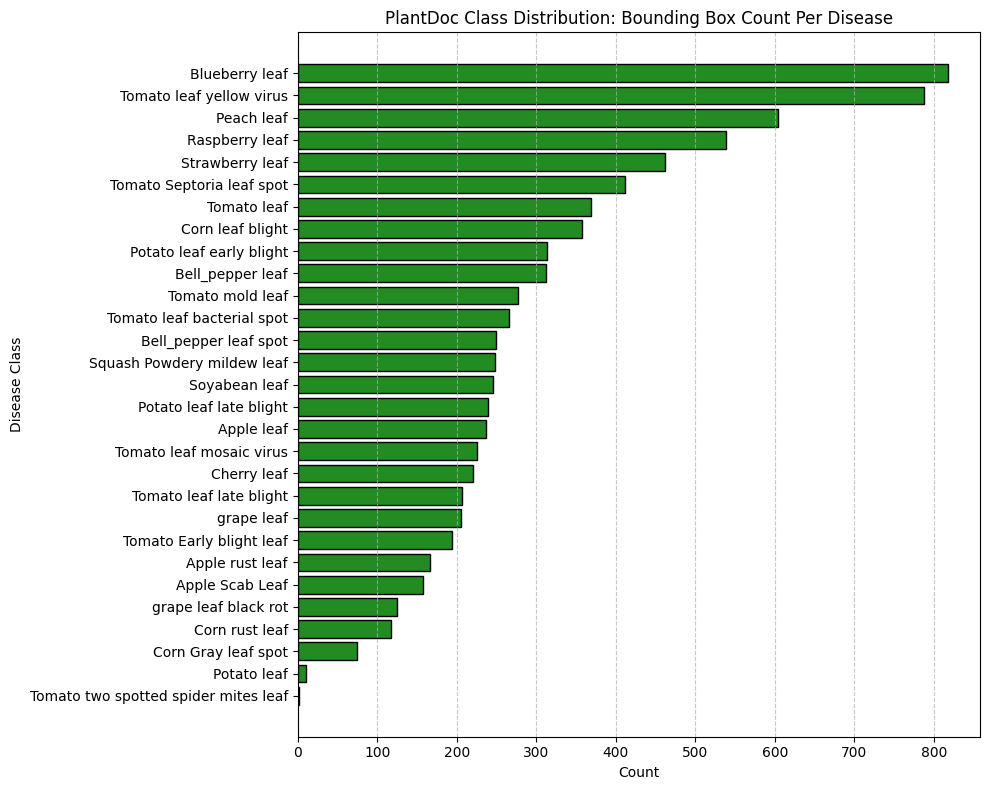

In [4]:
if 'coco_data' in locals():
    # Analyze the health of the PlantDoc dataset
    cat_ids = [ann['category_id'] for ann in coco_data['annotations']]
    counts = Counter(cat_ids)
    
    # Sort by frequency
    labels_values = [(categories.get(cid, 'Unknown'), count) for cid, count in counts.items()]
    labels_values.sort(key=lambda x: x[1])
    
    labels = [x[0] for x in labels_values]
    values = [x[1] for x in labels_values]

    plt.figure(figsize=(10, 8))
    plt.barh(labels, values, color='forestgreen', edgecolor='black')
    plt.title("PlantDoc Class Distribution: Bounding Box Count Per Disease")
    plt.xlabel("Count")
    plt.ylabel("Disease Class")
    plt.grid(axis='x', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()